In [3]:
"""
============================================================================
Task 4: Machine Translation (English → Kannada) using RNN/LSTM Model
============================================================================
- Single hidden layer LSTM Encoder
- Single hidden layer LSTM Decoder
- GloVe word embeddings for English (200d)
- FastText word embeddings for Kannada (200d)
- BLEU-1, 2, 3, 4 evaluation
- 5 training + 5 test example translations
============================================================================
"""

import torch
import torch.nn as nn
import torch.optim as optim
import random
import numpy as np
import csv
import time
import os
from collections import Counter
from torch.utils.data import DataLoader, Dataset
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence

# ============================================================================
# CONFIGURATION
# ============================================================================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

SOS_token = 0
EOS_token = 1
UNK_token = 2
PAD_token = 3

# Reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

# Hyperparameters
EMB_DIM = 200           # Embedding dimension (GloVe 200d)
HIDDEN_SIZE = 100       # Hidden layer size — as specified in task
N_LAYERS = 1            # Single hidden layer
DROPOUT = 0.3
BATCH_SIZE = 64
LEARNING_RATE = 0.001
EPOCHS = 20
MAX_LEN = 20            # Maximum sentence length
MIN_FREQ = 2            # Minimum word frequency for vocabulary
TEACHER_FORCING_RATIO = 0.5  # Fixed teacher forcing ratio

# ============================================================================
# FILE PATHS — UPDATE THESE
# ============================================================================
TRAIN_FILE = "/content/team23_kn_train.csv"    # ← TRAINING data
TEST_FILE = "/content/team23_kn_test.csv"      # ← SEPARATE test data
GLOVE_FILE = "/content/glove.6B.200d.txt"      # GloVe embeddings
FASTTEXT_FILE = "/content/wiki.kn.vec"         # FastText Kannada embeddings

# ============================================================================
# VOCABULARY
# ============================================================================
class Lang:
    def __init__(self, name, min_freq=2):
        self.name = name
        self.word2index = {"SOS": 0, "EOS": 1, "UNK": 2, "PAD": 3}
        self.index2word = {0: "SOS", 1: "EOS", 2: "UNK", 3: "PAD"}
        self.word2count = Counter()
        self.n_words = 4
        self.min_freq = min_freq

    def build_vocab(self, sentences):
        for s in sentences:
            for w in s.split():
                self.word2count[w] += 1
        for word, count in self.word2count.items():
            if count >= self.min_freq:
                self.word2index[word] = self.n_words
                self.index2word[self.n_words] = word
                self.n_words += 1
        print(f"  {self.name} vocab: {self.n_words} words "
              f"(filtered from {len(self.word2count)} unique, min_freq={self.min_freq})")

# ============================================================================
# DATA LOADING
# ============================================================================
def read_pairs(filepath):
    pairs = []
    with open(filepath, encoding='utf-8') as f:
        reader = csv.reader(f)
        next(reader)  # skip header
        for row in reader:
            if len(row) >= 2:
                src = row[0].strip().lower()
                tgt = row[1].strip()
                if src and tgt:
                    pairs.append((src, tgt))
    return pairs

def filter_pairs(pairs, max_len):
    return [(s, t) for s, t in pairs
            if 2 <= len(s.split()) <= max_len and 2 <= len(t.split()) <= max_len]

def sentence_to_indices(lang, sentence):
    return [lang.word2index.get(w, UNK_token) for w in sentence.split()] + [EOS_token]

# ============================================================================
# DATASET & DATALOADER
# ============================================================================
class TranslationDataset(Dataset):
    def __init__(self, pairs, src_lang, tgt_lang):
        self.data = []
        for src, tgt in pairs:
            src_ids = torch.tensor(sentence_to_indices(src_lang, src), dtype=torch.long)
            tgt_ids = torch.tensor(sentence_to_indices(tgt_lang, tgt), dtype=torch.long)
            self.data.append((src_ids, tgt_ids))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

def collate_fn(batch):
    srcs, tgts = zip(*batch)
    src_lens = torch.tensor([len(s) for s in srcs])
    srcs_padded = pad_sequence(srcs, batch_first=True, padding_value=PAD_token)
    tgts_padded = pad_sequence(tgts, batch_first=True, padding_value=PAD_token)
    return srcs_padded.to(DEVICE), tgts_padded.to(DEVICE), src_lens.to(DEVICE)

# ============================================================================
# PRETRAINED EMBEDDINGS
# ============================================================================
def load_glove(filepath, vocab, dim=200):
    if not os.path.exists(filepath):
        print(f"  GloVe not found at {filepath}, using random init")
        return None
    print(f"  Loading GloVe from {filepath}...")
    embeddings = {}
    with open(filepath, encoding='utf-8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            if word in vocab.word2index:
                embeddings[word] = np.asarray(values[1:], dtype='float32')
    matrix = np.random.normal(scale=0.1, size=(vocab.n_words, dim)).astype('float32')
    found = 0
    for word, idx in vocab.word2index.items():
        if word in embeddings:
            matrix[idx] = embeddings[word]
            found += 1
    print(f"  Found {found}/{vocab.n_words} words in GloVe")
    return torch.tensor(matrix, dtype=torch.float)

def load_fasttext(filepath, vocab, dim=200):
    if not os.path.exists(filepath):
        print(f"  FastText not found at {filepath}, using random init")
        return None
    print(f"  Loading FastText from {filepath}...")
    embeddings = {}
    with open(filepath, encoding='utf-8') as f:
        first_line = f.readline().strip().split()
        if len(first_line) != 2:
            f.seek(0)
        for line in f:
            values = line.rstrip().split(' ')
            word = values[0]
            if word in vocab.word2index:
                try:
                    embeddings[word] = np.asarray(values[1:dim+1], dtype='float32')
                except ValueError:
                    continue
    matrix = np.random.normal(scale=0.1, size=(vocab.n_words, dim)).astype('float32')
    found = 0
    for word, idx in vocab.word2index.items():
        if word in embeddings and len(embeddings[word]) == dim:
            matrix[idx] = embeddings[word]
            found += 1
    print(f"  Found {found}/{vocab.n_words} words in FastText")
    return torch.tensor(matrix, dtype=torch.float)

# ============================================================================
# MODEL: Simple LSTM Encoder-Decoder
# ============================================================================
class Encoder(nn.Module):
    """Single-layer LSTM Encoder."""
    def __init__(self, vocab_size, emb_dim, hidden_size, dropout=0.3, pretrained_emb=None):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD_token)
        if pretrained_emb is not None:
            self.embedding.weight.data.copy_(pretrained_emb)
        self.dropout = nn.Dropout(dropout)
        self.lstm = nn.LSTM(emb_dim, hidden_size, num_layers=1,
                           batch_first=True)

    def forward(self, src, src_lens):
        embedded = self.dropout(self.embedding(src))
        packed = pack_padded_sequence(embedded, src_lens.cpu(),
                                     batch_first=True, enforce_sorted=False)
        outputs, (hidden, cell) = self.lstm(packed)
        outputs, _ = pad_packed_sequence(outputs, batch_first=True)
        return outputs, hidden, cell


class Decoder(nn.Module):
    """Single-layer LSTM Decoder."""
    def __init__(self, vocab_size, emb_dim, hidden_size, dropout=0.3, pretrained_emb=None):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD_token)
        if pretrained_emb is not None:
            self.embedding.weight.data.copy_(pretrained_emb)
        self.dropout = nn.Dropout(dropout)
        self.lstm = nn.LSTM(emb_dim, hidden_size, num_layers=1,
                           batch_first=True)
        self.fc_out = nn.Linear(hidden_size, vocab_size)

    def forward(self, input_token, hidden, cell):
        embedded = self.dropout(self.embedding(input_token.unsqueeze(1)))  # (B, 1, E)
        output, (hidden, cell) = self.lstm(embedded, (hidden, cell))
        prediction = self.fc_out(output.squeeze(1))  # (B, vocab_size)
        return prediction, hidden, cell

# ============================================================================
# TRAINING
# ============================================================================
def train_epoch(encoder, decoder, loader, optimizer, criterion, tf_ratio):
    encoder.train()
    decoder.train()
    total_loss = 0
    n_batches = 0

    for src, tgt, src_lens in loader:
        optimizer.zero_grad()
        enc_outputs, hidden, cell = encoder(src, src_lens)

        batch_size = src.size(0)
        tgt_len = tgt.size(1)
        dec_input = torch.full((batch_size,), SOS_token, dtype=torch.long, device=DEVICE)
        loss = 0

        for t in range(tgt_len):
            output, hidden, cell = decoder(dec_input, hidden, cell)
            loss += criterion(output, tgt[:, t])

            if random.random() < tf_ratio:
                dec_input = tgt[:, t]
            else:
                dec_input = output.argmax(1)

        loss = loss / tgt_len
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            list(encoder.parameters()) + list(decoder.parameters()), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()
        n_batches += 1

    return total_loss / n_batches

# ============================================================================
# TRANSLATION
# ============================================================================
def translate(encoder, decoder, sentence, src_lang, tgt_lang, max_len=50):
    encoder.eval()
    decoder.eval()
    with torch.no_grad():
        src_ids = sentence_to_indices(src_lang, sentence)
        src_tensor = torch.tensor([src_ids], dtype=torch.long, device=DEVICE)
        src_len = torch.tensor([len(src_ids)], device=DEVICE)

        _, hidden, cell = encoder(src_tensor, src_len)
        dec_input = torch.tensor([SOS_token], dtype=torch.long, device=DEVICE)

        result = []
        for _ in range(max_len):
            output, hidden, cell = decoder(dec_input, hidden, cell)
            top1 = output.argmax(1)
            word_idx = top1.item()
            if word_idx == EOS_token:
                break
            word = tgt_lang.index2word.get(word_idx, None)
            if word and word not in ("UNK", "PAD", "SOS", "EOS"):
                result.append(word)
            dec_input = top1

    return " ".join(result)

# ============================================================================
# BLEU SCORE
# ============================================================================
def compute_bleu(pairs, encoder, decoder, src_lang, tgt_lang, n_samples=500):
    pairs = pairs[:n_samples]
    precisions = {1: [], 2: [], 3: [], 4: []}

    for src, tgt in pairs:
        hypothesis = translate(encoder, decoder, src, src_lang, tgt_lang).split()
        reference = tgt.split()

        for n in range(1, 5):
            if len(hypothesis) < n:
                precisions[n].append(0.0)
                continue
            ref_ngrams = Counter()
            hyp_ngrams = Counter()
            for i in range(len(reference) - n + 1):
                ref_ngrams[tuple(reference[i:i+n])] += 1
            for i in range(len(hypothesis) - n + 1):
                hyp_ngrams[tuple(hypothesis[i:i+n])] += 1
            clipped = sum(min(count, ref_ngrams.get(ng, 0))
                         for ng, count in hyp_ngrams.items())
            total = max(sum(hyp_ngrams.values()), 1)
            precisions[n].append(clipped / total)

    return {k: np.mean(v) for k, v in precisions.items()}

# ============================================================================
# MAIN
# ============================================================================
if __name__ == "__main__":
    print("=" * 70)
    print("Task 4: English → Kannada Machine Translation using RNN/LSTM")
    print("=" * 70)

    # --- Load Data ---
    print("\n[1] Loading data...")
    train_pairs = read_pairs(TRAIN_FILE)
    test_pairs = read_pairs(TEST_FILE)
    print(f"  Raw: train={len(train_pairs)}, test={len(test_pairs)}")

    train_pairs = filter_pairs(train_pairs, MAX_LEN)
    test_pairs = filter_pairs(test_pairs, MAX_LEN)
    print(f"  Filtered (≤{MAX_LEN} words): train={len(train_pairs)}, test={len(test_pairs)}")

    # --- Build Vocabularies ---
    print("\n[2] Building vocabularies...")
    src_lang = Lang("English", min_freq=MIN_FREQ)
    tgt_lang = Lang("Kannada", min_freq=MIN_FREQ)
    src_lang.build_vocab([p[0] for p in train_pairs])
    tgt_lang.build_vocab([p[1] for p in train_pairs])

    # --- Load Pretrained Embeddings ---
    print("\n[3] Loading embeddings...")
    src_emb = load_glove(GLOVE_FILE, src_lang, EMB_DIM)
    tgt_emb = load_fasttext(FASTTEXT_FILE, tgt_lang, EMB_DIM)

    # --- DataLoader ---
    print("\n[4] Creating data loaders...")
    train_dataset = TranslationDataset(train_pairs, src_lang, tgt_lang)
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                             shuffle=True, collate_fn=collate_fn)
    print(f"  {len(train_loader)} batches per epoch")

    # --- Build Model ---
    print("\n[5] Building model...")
    encoder = Encoder(src_lang.n_words, EMB_DIM, HIDDEN_SIZE,
                      DROPOUT, pretrained_emb=src_emb).to(DEVICE)
    decoder = Decoder(tgt_lang.n_words, EMB_DIM, HIDDEN_SIZE,
                      DROPOUT, pretrained_emb=tgt_emb).to(DEVICE)

    enc_params = sum(p.numel() for p in encoder.parameters())
    dec_params = sum(p.numel() for p in decoder.parameters())
    print(f"  Encoder params: {enc_params:,}")
    print(f"  Decoder params: {dec_params:,}")
    print(f"  Total params:   {enc_params + dec_params:,}")

    optimizer = optim.Adam(
        list(encoder.parameters()) + list(decoder.parameters()), lr=LEARNING_RATE)
    criterion = nn.CrossEntropyLoss(ignore_index=PAD_token)

    # --- Training ---
    # --- Training ---
    print("\n" + "=" * 70)
    print("TRAINING")
    print("=" * 70)

    best_bleu1 = 0
    loss_history = []   # ✅ store losses

    for epoch in range(1, EPOCHS + 1):
        t0 = time.time()

        avg_loss = train_epoch(
            encoder, decoder, train_loader,
            optimizer, criterion,
            TEACHER_FORCING_RATIO
        )

        loss_history.append(avg_loss)   # ✅ store loss

        elapsed = time.time() - t0

        if epoch % 5 == 0 or epoch == 1 or epoch == EPOCHS:
            bleu = compute_bleu(test_pairs, encoder, decoder, src_lang, tgt_lang, 300)

            print(f"Epoch {epoch:3d} | Loss: {avg_loss:.4f} | "
                  f"BLEU-1: {bleu[1]:.4f} | BLEU-2: {bleu[2]:.4f} | "
                  f"BLEU-3: {bleu[3]:.4f} | BLEU-4: {bleu[4]:.4f} | {elapsed:.1f}s")

            if bleu[1] > best_bleu1:
                best_bleu1 = bleu[1]
                torch.save({
                    'encoder': encoder.state_dict(),
                    'decoder': decoder.state_dict()
                }, 'best_model_task4.pt')
                print("  → New best! Saved model.")
        else:
            print(f"Epoch {epoch:3d} | Loss: {avg_loss:.4f} | {elapsed:.1f}s")

    # --- Load Best & Final Eval ---
    ckpt = torch.load('best_model_task4.pt', weights_only=False)
    encoder.load_state_dict(ckpt['encoder'])
    decoder.load_state_dict(ckpt['decoder'])

    print("\n" + "=" * 70)
    print("FINAL TEST SET EVALUATION")
    print("=" * 70)
    final_bleu = compute_bleu(test_pairs, encoder, decoder, src_lang, tgt_lang, 500)
    print(f"\n  BLEU-1: {final_bleu[1]:.4f}")
    print(f"  BLEU-2: {final_bleu[2]:.4f}")
    print(f"  BLEU-3: {final_bleu[3]:.4f}")
    print(f"  BLEU-4: {final_bleu[4]:.4f}")

    # --- Sample Translations ---
    print("\n" + "=" * 70)
    print("5 TRAINING EXAMPLES")
    print("=" * 70)
    for i, (src, tgt) in enumerate(random.sample(train_pairs, 5), 1):
        pred = translate(encoder, decoder, src, src_lang, tgt_lang)
        print(f"\n  Example {i}:")
        print(f"    Source (English) : {src}")
        print(f"    Ground Truth (KN): {tgt}")
        print(f"    Predicted (KN)   : {pred}")

    print("\n" + "=" * 70)
    print("5 TEST EXAMPLES")
    print("=" * 70)
    for i, (src, tgt) in enumerate(random.sample(test_pairs[:500], 5), 1):
        pred = translate(encoder, decoder, src, src_lang, tgt_lang)
        print(f"\n  Example {i}:")
        print(f"    Source (English) : {src}")
        print(f"    Ground Truth (KN): {tgt}")
        print(f"    Predicted (KN)   : {pred}")

    print("\n" + "=" * 70)
    print("DONE!")
    print("=" * 70)

Device: cuda
Task 4: English → Kannada Machine Translation using RNN/LSTM

[1] Loading data...
  Raw: train=70000, test=10000
  Filtered (≤20 words): train=62975, test=9028

[2] Building vocabularies...
  English vocab: 19695 words (filtered from 45124 unique, min_freq=2)
  Kannada vocab: 28565 words (filtered from 97713 unique, min_freq=2)

[3] Loading embeddings...
  Loading GloVe from /content/glove.6B.200d.txt...
  Found 11845/19695 words in GloVe
  Loading FastText from /content/wiki.kn.vec...
  Found 17720/28565 words in FastText

[4] Creating data loaders...
  984 batches per epoch

[5] Building model...
  Encoder params: 4,059,800
  Decoder params: 8,718,865
  Total params:   12,778,665

TRAINING
Epoch   1 | Loss: 6.3190 | BLEU-1: 0.0000 | BLEU-2: 0.0000 | BLEU-3: 0.0000 | BLEU-4: 0.0000 | 37.8s
Epoch   2 | Loss: 5.8415 | 39.7s
Epoch   3 | Loss: 5.6063 | 37.2s
Epoch   4 | Loss: 5.3624 | 37.1s
Epoch   5 | Loss: 5.1354 | BLEU-1: 0.0989 | BLEU-2: 0.0092 | BLEU-3: 0.0011 | BLEU-4: 

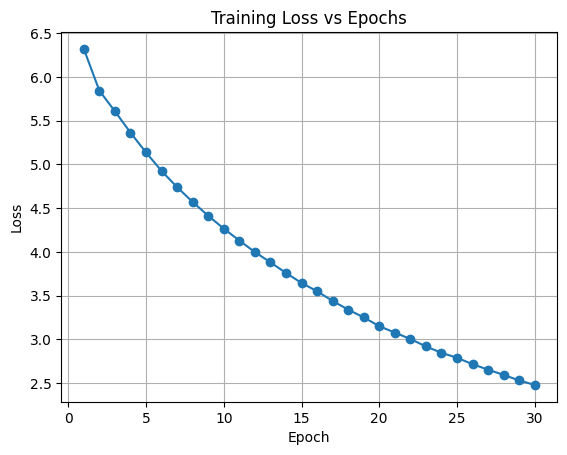

In [4]:
# --- LOSS PLOT ---
import matplotlib.pyplot as plt

plt.figure()
plt.plot(range(1, EPOCHS + 1), loss_history, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss vs Epochs")
plt.grid()

plt.savefig("loss_plot.png")  # saves file
plt.show()